In [1]:
import pandas as pd
import numpy as np
import time

start_time = time.time()

In [2]:
#Load Data
df = pd.read_parquet(r"C:\Users\Krant\OneDrive\Desktop\banknifty_data.parquet")

In [3]:
df.head()

,Unnamed: 0,Date,Ticker,Time,Open,High,Low,Close,Call/Put
0,0,2023-01-02,BANKNIFTY37000PE,09:15:59,3.40,3.40,2.85,3.00,PE
1,1,2023-01-02,BANKNIFTY43800CE,09:15:59,79.85,104.25,73.90,91.20,CE
2,2,2023-01-02,BANKNIFTY43900PE,09:15:59,867.95,883.15,826.75,826.75,PE
3,3,2023-01-02,BANKNIFTY44000PE,09:15:59,957.25,981.05,911.00,914.70,PE
4,4,2023-01-02,BANKNIFTY44200CE,09:15:59,37.90,42.95,27.35,37.10,CE


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10266681 entries, 0 to 10266680
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Unnamed: 0  int64  
 1   Date        object 
 2   Ticker      object 
 3   Time        object 
 4   Open        float64
 5   High        float64
 6   Low         float64
 7   Close       float64
 8   Call/Put    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 705.0+ MB


In [5]:
df.shape

(10266681, 9)

In [6]:
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

In [7]:
df['Date'] = pd.to_datetime(df['Date']) #changing data type

In [8]:
df['Strike'] = df['Ticker'].str.extract(r'(\d+)').astype(int)

In [9]:
df.head(1)

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike
0,2023-01-02,BANKNIFTY37000PE,09:15:59,3.4,3.4,2.85,3.0,PE,37000


In [10]:
df['WeekOfMonth'] = (df['Date'].dt.day - 1) // 7 + 1

In [11]:
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [12]:
df.head(1)

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek
0,2023-01-02,BANKNIFTY37000PE,09:15:59,3.4,3.4,2.85,3.0,PE,37000,1,0


In [13]:
# ---- Strike Selection (closest to Rs.50 at 09:20)

In [14]:
entry_candles = df[(df['Time'] == '09:20:59') & (df['WeekOfMonth'] == 1)]

In [15]:
entry_candles.head()

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek
522,2023-01-02,BANKNIFTY40500PE,09:20:59,8.45,9.05,8.40,8.75,PE,40500,1,0
523,2023-01-02,BANKNIFTY40800PE,09:20:59,10.25,10.95,10.20,10.80,PE,40800,1,0
524,2023-01-02,BANKNIFTY40900PE,09:20:59,11.10,11.90,10.95,11.65,PE,40900,1,0
525,2023-01-02,BANKNIFTY41000CE,09:20:59,2076.70,2090.00,2051.00,2090.00,CE,41000,1,0
526,2023-01-02,BANKNIFTY41100PE,09:20:59,13.10,14.20,12.95,13.90,PE,41100,1,0


In [16]:
ce_entry = entry_candles[entry_candles['Call/Put'] == 'CE'].copy()

In [17]:
pe_entry = entry_candles[entry_candles['Call/Put'] == 'PE'].copy()

In [18]:
ce_entry['diff_from_50'] = abs(ce_entry['Close'] - 50)

In [19]:
pe_entry['diff_from_50'] = abs(pe_entry['Close'] - 50)

In [20]:
ce_entry.head()

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek,diff_from_50
525,2023-01-02,BANKNIFTY41000CE,09:20:59,2076.70,2090.00,2051.00,2090.00,CE,41000,1,0,2040.00
532,2023-01-02,BANKNIFTY41700CE,09:20:59,1397.95,1398.10,1397.95,1398.10,CE,41700,1,0,1348.10
533,2023-01-02,BANKNIFTY41800CE,09:20:59,1270.25,1270.25,1270.25,1270.25,CE,41800,1,0,1220.25
536,2023-01-02,BANKNIFTY41500CE,09:20:59,1587.05,1600.00,1543.25,1596.05,CE,41500,1,0,1546.05
546,2023-01-02,BANKNIFTY42100CE,09:20:59,1021.75,1047.60,982.05,1001.20,CE,42100,1,0,951.20


In [21]:
pe_entry.head()

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek,diff_from_50
522,2023-01-02,BANKNIFTY40500PE,09:20:59,8.45,9.05,8.40,8.75,PE,40500,1,0,41.25
523,2023-01-02,BANKNIFTY40800PE,09:20:59,10.25,10.95,10.20,10.80,PE,40800,1,0,39.20
524,2023-01-02,BANKNIFTY40900PE,09:20:59,11.10,11.90,10.95,11.65,PE,40900,1,0,38.35
526,2023-01-02,BANKNIFTY41100PE,09:20:59,13.10,14.20,12.95,13.90,PE,41100,1,0,36.10
527,2023-01-02,BANKNIFTY41200PE,09:20:59,14.35,15.70,14.20,15.30,PE,41200,1,0,34.70


In [22]:
ce_selected = ce_entry.loc[ce_entry.groupby('Date')['diff_from_50'].idxmin()].reset_index(drop=True)

In [23]:
ce_selected.shape

(57, 12)

In [24]:
pe_selected = pe_entry.loc[pe_entry.groupby('Date')['diff_from_50'].idxmin()].reset_index(drop=True)

In [25]:
pe_selected.shape

(57, 12)

In [26]:
ce_selected.head()

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek,diff_from_50
0,2023-01-02,BANKNIFTY44000CE,09:20:59,50.8,51.7,44.35,50.05,CE,44000,1,0,0.05
1,2023-01-03,BANKNIFTY44000CE,09:20:59,45.3,46.6,43.85,45.15,CE,44000,1,1,4.85
2,2023-01-04,BANKNIFTY44000CE,09:20:59,38.6,42.5,38.60,40.95,CE,44000,1,2,9.05
3,2023-01-05,BANKNIFTY43300CE,09:20:59,64.6,67.3,58.80,58.80,CE,43300,1,3,8.80
4,2023-01-06,BANKNIFTY43600CE,09:20:59,54.1,55.2,51.65,52.85,CE,43600,1,4,2.85


In [27]:
# ---- Position Sizing ----

In [28]:
lot_size = 15

In [29]:
quantity = lot_size * 1

In [30]:
ce_selected['Quantity'] = quantity
pe_selected['Quantity'] = quantity

In [31]:
#Instead of writing 50 + 25 separately, we just say 50 × 1.5 

In [32]:
ce_selected['StopLossPrice'] = ce_selected['Close'] * 1.5
pe_selected['StopLossPrice'] = pe_selected['Close'] * 1.5

In [33]:
ce_selected.head(1)

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek,diff_from_50,Quantity,StopLossPrice
0,2023-01-02,BANKNIFTY44000CE,09:20:59,50.8,51.7,44.35,50.05,CE,44000,1,0,0.05,15,75.075


In [34]:
# ---- Stop Loss Detection ---

In [35]:
trade_window = df[(df['Time'] > '09:20:59') & (df['Time'] <= '15:20:59')]   #we need to see actual trade 9:20 to 15:20

In [36]:
#Now we can see CE trade window and PE Trade window

In [37]:
ce_full = trade_window.merge(ce_selected[['Date','Ticker','StopLossPrice']], on=['Date','Ticker'], how='inner')

In [38]:
pe_full = trade_window.merge(pe_selected[['Date','Ticker','StopLossPrice']], on=['Date','Ticker'], how='inner')

In [39]:
ce_full.head(1)

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek,StopLossPrice
0,2023-01-02,BANKNIFTY44000CE,09:21:59,50.15,50.15,45.5,46.1,CE,44000,1,0,75.075


In [40]:
ce_full['StopHit'] = ce_full['High'] >= ce_full['StopLossPrice'] # which one hited stop loss
pe_full['StopHit'] = pe_full['High'] >= pe_full['StopLossPrice']

In [41]:
ce_full.head(1)

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek,StopLossPrice,StopHit
0,2023-01-02,BANKNIFTY44000CE,09:21:59,50.15,50.15,45.5,46.1,CE,44000,1,0,75.075,False


In [42]:
pe_full.head(1)

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek,StopLossPrice,StopHit
0,2023-01-02,BANKNIFTY42000PE,09:21:59,46.7,51.0,46.0,48.85,PE,42000,1,0,70.2,False


In [43]:
# ---- Stopped-Out Trades ----
ce_stopped = ce_full[ce_full['StopHit']].groupby(['Date','Ticker']).first().reset_index()
ce_stopped.shape

(25, 13)

In [44]:
# So out of 57 CE trades:

# 25 trades hit stop loss and exited early
# # 32 trades (57-25) never hit stop loss, so they exited normally at 15:20

In [45]:
ce_stopped = ce_stopped[['Date','Ticker','Time','StopLossPrice']]
ce_stopped.head(4)

,Date,Ticker,Time,StopLossPrice
0,2023-01-02,BANKNIFTY44000CE,09:44:59,75.075
1,2023-01-05,BANKNIFTY43300CE,09:34:59,88.200
2,2023-02-01,BANKNIFTY42700CE,12:59:59,79.275
3,2023-02-02,BANKNIFTY40700CE,09:23:59,75.375


In [46]:
ce_stopped.columns = ['Date','Ticker','ExitTime','ExitPrice']
ce_stopped['ExitType'] = 'StopLoss'

In [47]:
ce_stopped = ce_stopped.merge(ce_selected[['Date','Ticker','Close','Quantity']], on=['Date','Ticker'])
ce_stopped = ce_stopped.rename(columns={'Close':'EntryPrice'})

In [48]:
ce_stopped.head()

,Date,Ticker,ExitTime,ExitPrice,ExitType,EntryPrice,Quantity
0,2023-01-02,BANKNIFTY44000CE,09:44:59,75.075,StopLoss,50.05,15
1,2023-01-05,BANKNIFTY43300CE,09:34:59,88.200,StopLoss,58.80,15
2,2023-02-01,BANKNIFTY42700CE,12:59:59,79.275,StopLoss,52.85,15
3,2023-02-02,BANKNIFTY40700CE,09:23:59,75.375,StopLoss,50.25,15
4,2023-03-01,BANKNIFTY40800CE,10:10:59,87.300,StopLoss,58.20,15


In [49]:
pe_stopped = pe_full[pe_full['StopHit']].groupby(['Date','Ticker']).first().reset_index()

In [50]:
pe_stopped.head()

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek,StopLossPrice,StopHit
0,2023-01-04,BANKNIFTY43000PE,09:43:59,74.00,83.3,73.95,81.85,PE,43000,1,2,82.275,True
1,2023-01-05,BANKNIFTY42800PE,09:22:59,64.95,97.8,62.90,88.00,PE,42800,1,3,89.775,True
2,2023-01-06,BANKNIFTY41300PE,10:14:59,61.45,70.2,61.00,68.90,PE,41300,1,4,70.200,True
3,2023-02-01,BANKNIFTY39000PE,14:45:59,52.55,76.6,52.55,73.15,PE,39000,1,2,70.950,True
4,2023-02-03,BANKNIFTY38700PE,11:30:59,66.10,77.0,65.45,71.60,PE,38700,1,4,73.425,True


In [51]:
pe_stopped = pe_stopped[['Date','Ticker','Time','StopLossPrice']]

In [52]:
pe_stopped.head()

,Date,Ticker,Time,StopLossPrice
0,2023-01-04,BANKNIFTY43000PE,09:43:59,82.275
1,2023-01-05,BANKNIFTY42800PE,09:22:59,89.775
2,2023-01-06,BANKNIFTY41300PE,10:14:59,70.200
3,2023-02-01,BANKNIFTY39000PE,14:45:59,70.950
4,2023-02-03,BANKNIFTY38700PE,11:30:59,73.425


In [53]:
pe_stopped.shape

(28, 4)

In [54]:
# So out of 57 PE trades:

# 28 trades hit stop loss and exited early
# 29 trades (57-28) never hit stop loss, so they exited normally at 15:20

In [55]:
pe_stopped.columns = ['Date','Ticker','ExitTime','ExitPrice']

In [56]:
pe_stopped['ExitType'] = 'StopLoss'

In [57]:
pe_stopped = pe_stopped.merge(pe_selected[['Date','Ticker','Close','Quantity']], on=['Date','Ticker'])
pe_stopped = pe_stopped.rename(columns={'Close':'EntryPrice'})

In [58]:
# CE: 25 out of 57 trades hit stop loss
# # PE: 28 out of 57 trades hit stop loss
# That's roughly 44-49% of trades getting stopped out on each leg 

In [59]:
# ---- Normal Exit Trades (15:20) ---- where trade not stopped
ce_not_stopped = ce_selected[~ce_selected['Date'].isin(ce_stopped['Date'])]

In [60]:
ce_not_stopped.shape

(32, 14)

In [61]:
ce_not_stopped.head()

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek,diff_from_50,Quantity,StopLossPrice
1,2023-01-03,BANKNIFTY44000CE,09:20:59,45.30,46.6,43.85,45.15,CE,44000,1,1,4.85,15,67.725
2,2023-01-04,BANKNIFTY44000CE,09:20:59,38.60,42.5,38.60,40.95,CE,44000,1,2,9.05,15,61.425
4,2023-01-06,BANKNIFTY43600CE,09:20:59,54.10,55.2,51.65,52.85,CE,43600,1,4,2.85,15,79.275
7,2023-02-03,BANKNIFTY42600CE,09:20:59,53.55,54.5,52.00,53.65,CE,42600,1,4,3.65,15,80.475
8,2023-02-06,BANKNIFTY42600CE,09:20:59,44.10,50.7,41.85,49.15,CE,42600,1,0,0.85,15,73.725


In [62]:
pe_not_stopped = pe_selected[~pe_selected['Date'].isin(pe_stopped['Date'])]

In [63]:
pe_not_stopped.shape

(29, 14)

In [64]:
pe_not_stopped.head()

,Date,Ticker,Time,Open,High,Low,Close,Call/Put,Strike,WeekOfMonth,DayOfWeek,diff_from_50,Quantity,StopLossPrice
0,2023-01-02,BANKNIFTY42000PE,09:20:59,44.90,49.40,43.50,46.80,PE,42000,1,0,3.20,15,70.200
1,2023-01-03,BANKNIFTY42500PE,09:20:59,44.70,47.90,43.60,46.50,PE,42500,1,1,3.50,15,69.750
6,2023-02-02,BANKNIFTY38700PE,09:20:59,50.90,58.00,46.65,48.15,PE,38700,1,3,1.85,15,72.225
8,2023-02-06,BANKNIFTY39800PE,09:20:59,54.90,58.15,50.05,50.75,PE,39800,1,0,0.75,15,76.125
10,2023-03-01,BANKNIFTY40000PE,09:20:59,56.85,56.85,53.10,53.95,PE,40000,1,2,3.95,15,80.925


In [65]:
# (32, 14) CE 32 trades (57-25) never hit stop loss, so they exited normally at 15:20
# (29, 14)  PE 29 trades (57-29) never hit stop loss, so they exited normally at 15:20
# total trade is 57

In [66]:
exit_candles = df[df['Time'] == '15:20:59']

In [67]:
ce_normal = ce_not_stopped.merge(exit_candles[['Date','Ticker','Close']], on=['Date','Ticker'], suffixes=('_entry','_exit'))

In [68]:
ce_normal.head()

,Date,Ticker,Time,Open,High,Low,Close_entry,Call/Put,Strike,WeekOfMonth,DayOfWeek,diff_from_50,Quantity,StopLossPrice,Close_exit
0,2023-01-03,BANKNIFTY44000CE,09:20:59,45.30,46.6,43.85,45.15,CE,44000,1,1,4.85,15,67.725,43.70
1,2023-01-04,BANKNIFTY44000CE,09:20:59,38.60,42.5,38.60,40.95,CE,44000,1,2,9.05,15,61.425,10.70
2,2023-01-06,BANKNIFTY43600CE,09:20:59,54.10,55.2,51.65,52.85,CE,43600,1,4,2.85,15,79.275,23.55
3,2023-02-03,BANKNIFTY42600CE,09:20:59,53.55,54.5,52.00,53.65,CE,42600,1,4,3.65,15,80.475,49.00
4,2023-02-06,BANKNIFTY42600CE,09:20:59,44.10,50.7,41.85,49.15,CE,42600,1,0,0.85,15,73.725,29.25


In [69]:
ce_normal = ce_normal[['Date','Ticker','Close_entry','Close_exit','Quantity']]

In [70]:
ce_normal.columns = ['Date','Ticker','EntryPrice','ExitPrice','Quantity']

In [71]:
ce_normal.head()

,Date,Ticker,EntryPrice,ExitPrice,Quantity
0,2023-01-03,BANKNIFTY44000CE,45.15,43.70,15
1,2023-01-04,BANKNIFTY44000CE,40.95,10.70,15
2,2023-01-06,BANKNIFTY43600CE,52.85,23.55,15
3,2023-02-03,BANKNIFTY42600CE,53.65,49.00,15
4,2023-02-06,BANKNIFTY42600CE,49.15,29.25,15


In [72]:
ce_normal['ExitTime'] = '15:20:59' #adding
ce_normal['ExitType'] = 'TimeExit'

In [73]:
ce_normal.head()

,Date,Ticker,EntryPrice,ExitPrice,Quantity,ExitTime,ExitType
0,2023-01-03,BANKNIFTY44000CE,45.15,43.70,15,15:20:59,TimeExit
1,2023-01-04,BANKNIFTY44000CE,40.95,10.70,15,15:20:59,TimeExit
2,2023-01-06,BANKNIFTY43600CE,52.85,23.55,15,15:20:59,TimeExit
3,2023-02-03,BANKNIFTY42600CE,53.65,49.00,15,15:20:59,TimeExit
4,2023-02-06,BANKNIFTY42600CE,49.15,29.25,15,15:20:59,TimeExit


In [74]:
pe_normal = pe_not_stopped.merge(exit_candles[['Date','Ticker','Close']], on=['Date','Ticker'], suffixes=('_entry','_exit'))

In [75]:
pe_normal = pe_normal[['Date','Ticker','Close_entry','Close_exit','Quantity']]
pe_normal.columns = ['Date','Ticker','EntryPrice','ExitPrice','Quantity']

In [76]:
pe_normal['ExitTime'] = '15:20:59'
pe_normal['ExitType'] = 'TimeExit'

In [77]:
pe_normal.head()

,Date,Ticker,EntryPrice,ExitPrice,Quantity,ExitTime,ExitType
0,2023-01-02,BANKNIFTY42000PE,46.80,19.35,15,15:20:59,TimeExit
1,2023-01-03,BANKNIFTY42500PE,46.50,20.45,15,15:20:59,TimeExit
2,2023-02-02,BANKNIFTY38700PE,48.15,0.20,15,15:20:59,TimeExit
3,2023-02-06,BANKNIFTY39800PE,50.75,35.75,15,15:20:59,TimeExit
4,2023-03-01,BANKNIFTY40000PE,53.95,13.80,15,15:20:59,TimeExit


In [78]:
# ---- Combine Tradesheet ----
ce_stopped['OptionType'] = 'CE'
ce_normal['OptionType'] = 'CE'
pe_stopped['OptionType'] = 'PE'
pe_normal['OptionType'] = 'PE'

In [79]:
ce_stopped.head()

,Date,Ticker,ExitTime,ExitPrice,ExitType,EntryPrice,Quantity,OptionType
0,2023-01-02,BANKNIFTY44000CE,09:44:59,75.075,StopLoss,50.05,15,CE
1,2023-01-05,BANKNIFTY43300CE,09:34:59,88.200,StopLoss,58.80,15,CE
2,2023-02-01,BANKNIFTY42700CE,12:59:59,79.275,StopLoss,52.85,15,CE
3,2023-02-02,BANKNIFTY40700CE,09:23:59,75.375,StopLoss,50.25,15,CE
4,2023-03-01,BANKNIFTY40800CE,10:10:59,87.300,StopLoss,58.20,15,CE


In [80]:
ce_normal.head()

,Date,Ticker,EntryPrice,ExitPrice,Quantity,ExitTime,ExitType,OptionType
0,2023-01-03,BANKNIFTY44000CE,45.15,43.70,15,15:20:59,TimeExit,CE
1,2023-01-04,BANKNIFTY44000CE,40.95,10.70,15,15:20:59,TimeExit,CE
2,2023-01-06,BANKNIFTY43600CE,52.85,23.55,15,15:20:59,TimeExit,CE
3,2023-02-03,BANKNIFTY42600CE,53.65,49.00,15,15:20:59,TimeExit,CE
4,2023-02-06,BANKNIFTY42600CE,49.15,29.25,15,15:20:59,TimeExit,CE


In [81]:
pe_stopped.head()

,Date,Ticker,ExitTime,ExitPrice,ExitType,EntryPrice,Quantity,OptionType
0,2023-01-04,BANKNIFTY43000PE,09:43:59,82.275,StopLoss,54.85,15,PE
1,2023-01-05,BANKNIFTY42800PE,09:22:59,89.775,StopLoss,59.85,15,PE
2,2023-01-06,BANKNIFTY41300PE,10:14:59,70.200,StopLoss,46.80,15,PE
3,2023-02-01,BANKNIFTY39000PE,14:45:59,70.950,StopLoss,47.30,15,PE
4,2023-02-03,BANKNIFTY38700PE,11:30:59,73.425,StopLoss,48.95,15,PE


In [82]:
pe_normal.head()

,Date,Ticker,EntryPrice,ExitPrice,Quantity,ExitTime,ExitType,OptionType
0,2023-01-02,BANKNIFTY42000PE,46.80,19.35,15,15:20:59,TimeExit,PE
1,2023-01-03,BANKNIFTY42500PE,46.50,20.45,15,15:20:59,TimeExit,PE
2,2023-02-02,BANKNIFTY38700PE,48.15,0.20,15,15:20:59,TimeExit,PE
3,2023-02-06,BANKNIFTY39800PE,50.75,35.75,15,15:20:59,TimeExit,PE
4,2023-03-01,BANKNIFTY40000PE,53.95,13.80,15,15:20:59,TimeExit,PE


In [83]:
tradesheet = pd.concat([ce_stopped, ce_normal, pe_stopped, pe_normal], ignore_index=True)
tradesheet = tradesheet.sort_values('Date').reset_index(drop=True)#shorted by date

In [84]:
tradesheet.head()

,Date,Ticker,ExitTime,ExitPrice,ExitType,EntryPrice,Quantity,OptionType
0,2023-01-02,BANKNIFTY44000CE,09:44:59,75.075,StopLoss,50.05,15,CE
1,2023-01-02,BANKNIFTY42000PE,15:20:59,19.350,TimeExit,46.80,15,PE
2,2023-01-03,BANKNIFTY42500PE,15:20:59,20.450,TimeExit,46.50,15,PE
3,2023-01-03,BANKNIFTY44000CE,15:20:59,43.700,TimeExit,45.15,15,CE
4,2023-01-04,BANKNIFTY43000PE,09:43:59,82.275,StopLoss,54.85,15,PE


In [85]:
# ---- P&L ----
tradesheet['EntryValue'] = tradesheet['EntryPrice'] * tradesheet['Quantity']
tradesheet['ExitValue'] = tradesheet['ExitPrice'] * tradesheet['Quantity']
tradesheet['GrossPnL'] = tradesheet['EntryValue'] - tradesheet['ExitValue']

In [86]:
tradesheet.sort_values(by='GrossPnL', ascending=False).head()

,Date,Ticker,ExitTime,ExitPrice,ExitType,EntryPrice,Quantity,OptionType,EntryValue,ExitValue,GrossPnL
43,2023-06-01,BANKNIFTY44200CE,15:20:59,0.1,TimeExit,62.05,15,CE,930.75,1.5,929.25
59,2023-07-06,BANKNIFTY44900PE,15:20:59,0.1,TimeExit,55.00,15,PE,825.00,1.5,823.50
23,2023-03-02,BANKNIFTY40900CE,15:20:59,0.1,TimeExit,48.60,15,CE,729.00,1.5,727.50
12,2023-02-02,BANKNIFTY38700PE,15:20:59,0.2,TimeExit,48.15,15,PE,722.25,3.0,719.25
91,2023-11-01,BANKNIFTY43000CE,15:20:59,0.1,TimeExit,46.00,15,CE,690.00,1.5,688.50


In [87]:
print("Pipeline runtime:", round(time.time() - start_time, 2), "seconds")
print(tradesheet.shape)
print(tradesheet.head(10))

Pipeline runtime: 48.64 seconds
(114, 11)
        Date            Ticker  ExitTime  ExitPrice  ExitType  EntryPrice  \
0 2023-01-02  BANKNIFTY44000CE  09:44:59     75.075  StopLoss       50.05   
1 2023-01-02  BANKNIFTY42000PE  15:20:59     19.350  TimeExit       46.80   
2 2023-01-03  BANKNIFTY42500PE  15:20:59     20.450  TimeExit       46.50   
3 2023-01-03  BANKNIFTY44000CE  15:20:59     43.700  TimeExit       45.15   
4 2023-01-04  BANKNIFTY43000PE  09:43:59     82.275  StopLoss       54.85   
5 2023-01-04  BANKNIFTY44000CE  15:20:59     10.700  TimeExit       40.95   
6 2023-01-05  BANKNIFTY43300CE  09:34:59     88.200  StopLoss       58.80   
7 2023-01-05  BANKNIFTY42800PE  09:22:59     89.775  StopLoss       59.85   
8 2023-01-06  BANKNIFTY41300PE  10:14:59     70.200  StopLoss       46.80   
9 2023-01-06  BANKNIFTY43600CE  15:20:59     23.550  TimeExit       52.85   

   Quantity OptionType  EntryValue  ExitValue  GrossPnL  
0        15         CE      750.75   1126.125  -375.

In [88]:
# ---- Daily P&L and NAV ----
daily_pnl = tradesheet.groupby('Date')['GrossPnL'].sum().reset_index()
daily_pnl.columns = ['Date','DailyPnL']
daily_pnl.head()

,Date,DailyPnL
0,2023-01-02,36.375
1,2023-01-03,412.500
2,2023-01-04,42.375
3,2023-01-05,-889.875
4,2023-01-06,88.500


In [89]:
daily_pnl = daily_pnl.sort_values('Date').reset_index(drop=True)

In [90]:
daily_pnl['CumulativePnL'] = daily_pnl['DailyPnL'].cumsum()

In [91]:
daily_pnl.head()

,Date,DailyPnL,CumulativePnL
0,2023-01-02,36.375,36.375
1,2023-01-03,412.500,448.875
2,2023-01-04,42.375,491.250
3,2023-01-05,-889.875,-398.625
4,2023-01-06,88.500,-310.125


In [92]:
starting_capital = 100000 # Assumption: assignment did not specify starting capital, 
                            # so Rs.1,00,000 is chosen as a reasonable base for NAV calculation
daily_pnl['NAV'] = 100 + (daily_pnl['CumulativePnL'] / starting_capital) * 100

In [93]:
# ---- Drawdown ----
daily_pnl['RunningMax'] = daily_pnl['NAV'].cummax()
daily_pnl['Drawdown'] = (daily_pnl['NAV'] - daily_pnl['RunningMax']) / daily_pnl['RunningMax'] * 100
max_drawdown = daily_pnl['Drawdown'].min()

In [94]:
daily_pnl.head()

,Date,DailyPnL,CumulativePnL,NAV,RunningMax,Drawdown
0,2023-01-02,36.375,36.375,100.036375,100.036375,0.000000
1,2023-01-03,412.500,448.875,100.448875,100.448875,0.000000
2,2023-01-04,42.375,491.250,100.491250,100.491250,0.000000
3,2023-01-05,-889.875,-398.625,99.601375,100.491250,-0.885525
4,2023-01-06,88.500,-310.125,99.689875,100.491250,-0.797457


In [95]:
# ---CAGR (Compound Annual Growth Rate) 
start_nav = 100       #pythonstart_nav = 100  # NAV starts at 100 as a baseline index value (like a stock index, e.g. Nifty 50 base = 1000)
                      # This makes it easy to read % returns directly: NAV of 105 = +5% gain, NAV of 95
end_nav = daily_pnl['NAV'].iloc[-1]
start_date = daily_pnl['Date'].iloc[0]
end_date = daily_pnl['Date'].iloc[-1]
years = (end_date - start_date).days / 365.25
cagr = ((end_nav / start_nav) ** (1/years) - 1) * 100


In [96]:
print("CAGR:", round(cagr,2), "%")
print("Max Drawdown:", round(max_drawdown,2), "%")
print(daily_pnl.head(5))

CAGR: 4.59 %
Max Drawdown: -2.69 %
        Date  DailyPnL  CumulativePnL         NAV  RunningMax  Drawdown
0 2023-01-02    36.375         36.375  100.036375  100.036375  0.000000
1 2023-01-03   412.500        448.875  100.448875  100.448875  0.000000
2 2023-01-04    42.375        491.250  100.491250  100.491250  0.000000
3 2023-01-05  -889.875       -398.625   99.601375  100.491250 -0.885525
4 2023-01-06    88.500       -310.125   99.689875  100.491250 -0.797457


In [97]:
# ---- Win/Loss Stats ----
tradesheet['IsWin'] = tradesheet['GrossPnL'] > 0
tradesheet['DayOfWeek'] = tradesheet['Date'].dt.dayofweek
tradesheet['IsExpiry'] = tradesheet['DayOfWeek'] == 2
tradesheet['PctPnL'] = (tradesheet['GrossPnL'] / tradesheet['EntryValue']) * 100

In [98]:
tradesheet.head()

,Date,Ticker,ExitTime,ExitPrice,ExitType,EntryPrice,Quantity,OptionType,EntryValue,ExitValue,GrossPnL,IsWin,DayOfWeek,IsExpiry,PctPnL
0,2023-01-02,BANKNIFTY44000CE,09:44:59,75.075,StopLoss,50.05,15,CE,750.75,1126.125,-375.375,False,0,False,-50.000000
1,2023-01-02,BANKNIFTY42000PE,15:20:59,19.350,TimeExit,46.80,15,PE,702.00,290.250,411.750,True,0,False,58.653846
2,2023-01-03,BANKNIFTY42500PE,15:20:59,20.450,TimeExit,46.50,15,PE,697.50,306.750,390.750,True,1,False,56.021505
3,2023-01-03,BANKNIFTY44000CE,15:20:59,43.700,TimeExit,45.15,15,CE,677.25,655.500,21.750,True,1,False,3.211517
4,2023-01-04,BANKNIFTY43000PE,09:43:59,82.275,StopLoss,54.85,15,PE,822.75,1234.125,-411.375,False,2,True,-50.000000


In [99]:
total_trades = len(tradesheet)
total_wins = tradesheet['IsWin'].sum()
total_losses = total_trades - total_wins

In [101]:
ce_wins = tradesheet[tradesheet['OptionType']=='CE']['IsWin'].sum()
ce_total = len(tradesheet[tradesheet['OptionType']=='CE'])
pe_wins = tradesheet[tradesheet['OptionType']=='PE']['IsWin'].sum()
pe_total = len(tradesheet[tradesheet['OptionType']=='PE'])


In [104]:
print("Total trades:", total_trades, "| Wins:", total_wins, "| Losses:", total_losses)
print("Win %:", round(total_wins/total_trades*100,2), "| Loss %:", round(total_losses/total_trades*100,2))
print("CE Win%:", round(ce_wins/ce_total*100,2), "| PE Win%:", round(pe_wins/pe_total*100,2))


Total trades: 114 | Wins: 61 | Losses: 53
Win %: 53.51 | Loss %: 46.49
CE Win%: 56.14 | PE Win%: 50.88


In [105]:
expiry_avg = tradesheet.groupby(['OptionType','IsExpiry'])['PctPnL'].mean().reset_index()
print(expiry_avg)

  OptionType  IsExpiry     PctPnL
0         CE     False   2.039248
1         CE      True  27.232472
2         PE     False   5.214639
3         PE      True  -0.351645


In [106]:
# ---- Monthly P&L ----
daily_pnl['Month'] = daily_pnl['Date'].dt.to_period('M')


monthly_nav = daily_pnl.groupby('Month')['NAV'].last().reset_index()

monthly_nav['PrevNAV'] = monthly_nav['NAV'].shift(1)
monthly_nav['PrevNAV'] = monthly_nav['PrevNAV'].fillna(100)
monthly_nav['MonthlyPctPnL'] = ((monthly_nav['NAV'] - monthly_nav['PrevNAV']) / monthly_nav['PrevNAV']) * 100

print(monthly_nav[['Month','NAV','MonthlyPctPnL']])

      Month         NAV  MonthlyPctPnL
0   2023-01   99.689875      -0.310125
1   2023-02   99.397750      -0.293034
2   2023-03  100.062625       0.668903
3   2023-04  101.260750       1.197375
4   2023-05  102.166375       0.894349
5   2023-06  103.601875       1.405061
6   2023-07  103.195000      -0.392729
7   2023-08  101.657875      -1.489534
8   2023-09  101.941750       0.279245
9   2023-10  104.509000       2.518350
10  2023-11  103.960750      -0.524596
11  2023-12  104.400625       0.423116
12  2024-01  104.582125       0.173850


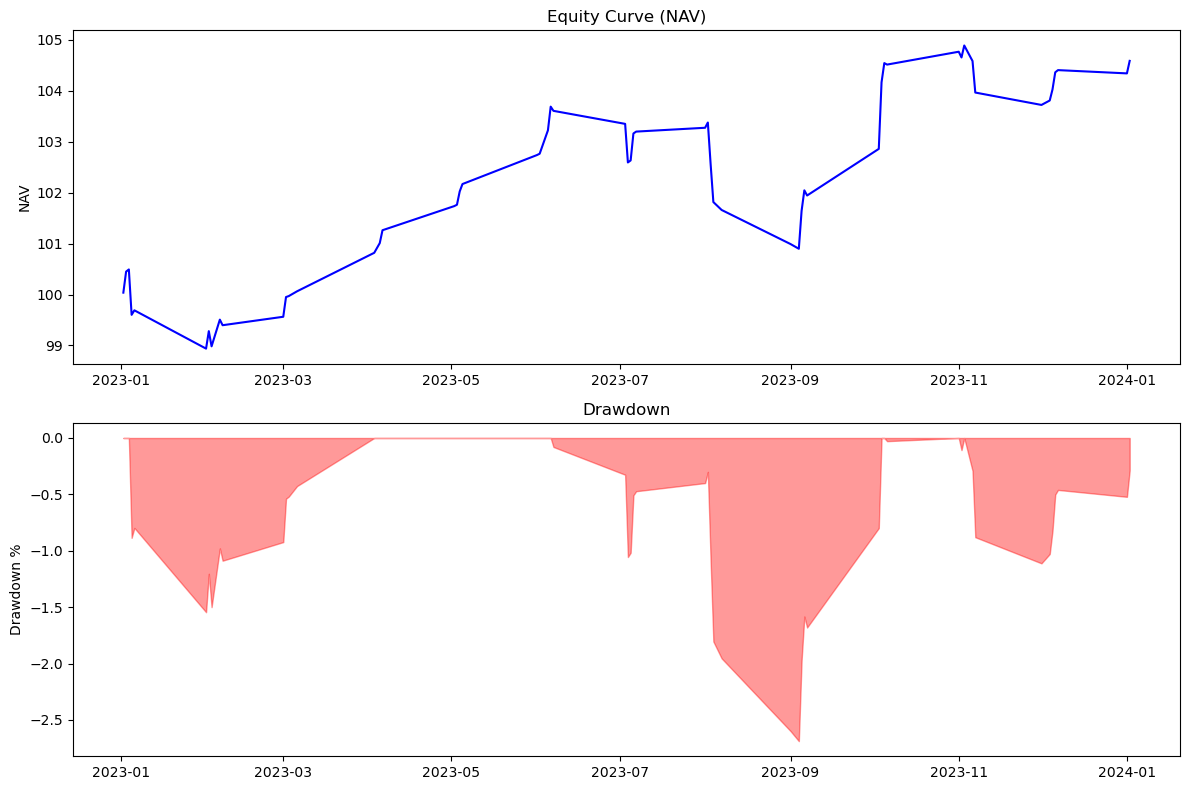

In [107]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12,8))
axes[0].plot(daily_pnl['Date'], daily_pnl['NAV'], color='blue')
axes[0].set_title('Equity Curve (NAV)')
axes[0].set_ylabel('NAV')

axes[1].fill_between(daily_pnl['Date'], daily_pnl['Drawdown'], 0, color='red', alpha=0.4)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown %')

plt.tight_layout()
plt.savefig('equity_drawdown.png')
plt.show()

In [ ]:
# RunningMax tracks the highest NAV reached so far (the peak), updated continuously as we move through each day

In [109]:
# Drawdown = % fall from that peak to today's NAV. 0% means we're at a new high; negative means we're below a previous peak
# Max Drawdown = the single worst (most negative) drawdown experienced at any point during the year

In [111]:
with pd.ExcelWriter('Qode_Backtest_Submission.xlsx', engine='xlsxwriter') as writer:
    
    guide_data = {
        'Section': ['Objective', 'Strategy', 'Entry Time', 'Exit Time', 'Stop Loss', 
                    'Lot Size', 'Starting Capital', 'Data Scope', 'Assumptions', 'Runtime'],
        'Description': [
            '09:20 AM Short Strangle Backtest on BANKNIFTY',
            'Sell CE and PE with premium closest to Rs.50 at entry',
            '09:20:59 (1-min close)',
            '15:20:59 (1-min close) or stop loss, whichever first',
            '50% on entry price, checked using High column',
            '15 (1 lot)',
            'Rs.1,00,000 (assumed, not specified in assignment)',
            'Week 1 of each month, all 12 months, Wednesday as expiry day',
            'No BANKNIFTY index data was provided in the dataset, so underlying close price column is not available in tradesheet',
            'Approx 90 seconds (data load + full backtest processing)'
        ]
    }
    pd.DataFrame(guide_data).to_excel(writer, sheet_name='Guide', index=False)
    
    tradesheet.to_excel(writer, sheet_name='Tradesheet', index=False)
    
    stats_data = {
        'Metric': ['CAGR (%)', 'Max Drawdown (%)', 'Total Trades', 'Total Wins', 'Total Losses',
                   'Win %', 'Loss %', 'CE Win %', 'PE Win %'],
        'Value': [round(cagr,2), round(max_drawdown,2), total_trades, total_wins, total_losses,
                  round(total_wins/total_trades*100,2), round(total_losses/total_trades*100,2),
                  round(ce_wins/ce_total*100,2), round(pe_wins/pe_total*100,2)]
    }
    pd.DataFrame(stats_data).to_excel(writer, sheet_name='Stats', index=False)

print("Saved successfully!")

Saved successfully!
